In [ ]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import seaborn as sns
from mpl_toolkits.axes_grid1 import make_axes_locatable
from pandas import set_option
set_option("display.max_rows", 10)
pd.options.mode.chained_assignment = None

In [ ]:
df = pd.read_csv("/content/All_Well_combined.csv")
df.head()

,DEPT[M],WELL,CALIPER[MM],DEN[GM/CC],RES(64N),RES[OHM],SP[MV],GAM[API],LITHOLOGY DESCRIPTION,Formation,FaciesLabels
0,24.00,1,12.6696,2.59367,4.50623,21.0600,64.5311,77.5320,"Fine graineded SST, brown",Raniganj,Sandstone (SST)
1,24.89,1,12.6886,2.30613,3.39083,22.2852,56.2742,79.1260,"Fine graineded SST, brown",Raniganj,Sandstone (SST)
2,25.19,1,12.6710,2.37167,3.29750,21.9935,56.3978,78.5932,Carb shale,Raniganj,Carb Shale
3,25.64,1,12.6645,2.32154,3.11173,22.5185,48.2233,74.8741,Grey Shale,Raniganj,Grey Shale
4,25.95,1,12.6589,1.97248,4.36571,22.5186,32.1008,109.9220,Siltstone,Raniganj,Siltstone


In [ ]:
df.shape

(2520, 11)

In [ ]:
df.isna().sum()

,0
DEPT[M],0
WELL,0
CALIPER[MM],0
DEN[GM/CC],0
RES(64N),0
...,...
SP[MV],0
GAM[API],0
LITHOLOGY DESCRIPTION,0
Formation,0


In [ ]:
df['FaciesLabels'].unique()

array(['Sandstone (SST)', 'Carb Shale', 'Grey Shale', 'Siltstone', 'dgs',
       'coal', 'ss', 'alt', 'Carb shale', 'Shale'], dtype=object)

In [ ]:
df.loc[df['FaciesLabels'] == 'Carb shale']

,DEPT[M],WELL,CALIPER[MM],DEN[GM/CC],RES(64N),RES[OHM],SP[MV],GAM[API],LITHOLOGY DESCRIPTION,Formation,FaciesLabels
574,32.320,2,14.41450,2.14104,14.3236,65.7496,46.5384,163.658,Carbonaceous shale with Shale band,Raniganj,Carb shale
580,32.990,2,14.93960,2.10149,22.9270,56.1102,46.3158,158.127,Carbonaceous shale,Raniganj,Carb shale
625,58.067,2,12.95700,2.10485,17.4790,71.3713,36.4618,268.756,Carbonaceous Shale,Raniganj,Carb shale
671,81.347,2,14.37290,1.87260,10.3423,73.2220,26.0615,180.253,Carbonaceous shale,Raniganj,Carb shale
672,81.417,2,14.37250,1.91047,11.6217,71.8935,26.0615,211.367,Carbonaceous shale with shale band,Raniganj,Carb shale
...,...,...,...,...,...,...,...,...,...,...,...
890,304.197,2,10.49260,2.24656,37.5710,74.4450,114.2120,307.477,Carb. Shale,Raniganj,Carb shale
1126,823.470,2,7.55330,2.30242,29.8826,89.6493,119.2600,243.865,Carbonaceous shale,Barakar,Carb shale
1169,861.760,2,7.48821,2.38286,62.6488,104.0980,117.8640,188.550,Carbonaceous shale,Barakar,Carb shale
1174,863.000,2,7.49741,1.96163,39.4472,114.8900,118.3490,183.019,Carbonaceous shale,Barakar,Carb shale


In [ ]:
df['FaciesLabels'] = df['FaciesLabels'].replace('Carb shale', 'Carb Shale')


In [ ]:
df['FaciesLabels'].unique()

array(['Sandstone (SST)', 'Carb Shale', 'Grey Shale', 'Siltstone', 'dgs',
       'coal', 'ss', 'alt', 'Shale'], dtype=object)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2520 entries, 0 to 2519
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   DEPT[M]                2520 non-null   float64
 1   WELL                   2520 non-null   int64  
 2   CALIPER[MM]            2520 non-null   float64
 3   DEN[GM/CC]             2520 non-null   float64
 4   RES(64N)               2520 non-null   float64
 5   RES[OHM]               2520 non-null   float64
 6   SP[MV]                 2520 non-null   float64
 7   GAM[API]               2520 non-null   float64
 8   LITHOLOGY DESCRIPTION  2520 non-null   object 
 9   Formation              2520 non-null   object 
 10  FaciesLabels           2520 non-null   object 
dtypes: float64(7), int64(1), object(3)
memory usage: 216.7+ KB


In [ ]:
df['WELL'] = df['WELL'].astype('object')
df['WELL'].unique()

array([1, 2, 3, 4], dtype=object)

In [ ]:
df['FaciesLabels'].unique()

array(['Sandstone (SST)', 'Carb Shale', 'Grey Shale', 'Siltstone', 'dgs',
       'coal', 'ss', 'alt', 'Shale'], dtype=object)

In [ ]:
unique_classes = df['FaciesLabels'].unique()
class_mapping = {
                  'Sandstone (SST)': 0,
                  'alt': 1,
                  'Carb Shale': 2,
                  'Grey Shale': 3,
                  'dgs': 4,
                  'coal': 5,
                  'ss': 6,
                  'Siltstone': 7,
                  'Shale':8
                  }

class_mapping

{'Sandstone (SST)': 0,
 'alt': 1,
 'Carb Shale': 2,
 'Grey Shale': 3,
 'dgs': 4,
 'coal': 5,
 'ss': 6,
 'Siltstone': 7,
 'Shale': 8}

In [ ]:
df['Facies'] = df['FaciesLabels'].map(class_mapping)
df.sample(4)

,DEPT[M],WELL,CALIPER[MM],DEN[GM/CC],RES(64N),RES[OHM],SP[MV],GAM[API],LITHOLOGY DESCRIPTION,Formation,FaciesLabels,Facies
2186,712.60,4,9.00922,2.68000,88.40000,60.3000,-33.2457,177.700,ALT SH/SST,Raniganj,alt,1
401,445.00,1,10.14840,2.39197,8.35986,23.6270,-156.3650,242.153,Dark grey shale,Barren Measures,dgs,4
1000,556.85,2,7.60708,2.25814,10.79990,44.5626,113.5330,265.991,Dark grey shale,Barren Measures,dgs,4
2446,1019.75,4,7.56760,2.45501,98.29940,112.2930,89.6006,145.477,SANDY SHALE,Barren Measures,ss,6


In [ ]:
df.describe()

,DEPT[M],CALIPER[MM],DEN[GM/CC],RES(64N),RES[OHM],SP[MV],GAM[API],Facies
count,2520.000000,2520.000000,2520.000000,2520.000000,2520.000000,2520.000000,2520.000000,2520.000000
mean,424.586454,10.061833,2.440275,74.114343,78.610664,15.403467,132.266800,2.532143
std,284.691710,3.193847,0.293583,69.878900,52.029629,88.219472,121.033983,2.432690
min,24.000000,5.080000,1.060320,-9.613840,17.368400,-240.519000,-128.850000,0.000000
25%,179.312000,7.661912,2.324045,20.496850,52.958125,-37.325000,92.430175,0.000000
50%,365.500000,9.539170,2.450000,53.839500,66.800550,20.425900,164.612500,3.000000
75%,643.565000,11.332550,2.639985,105.700000,90.194175,88.400000,216.899250,5.000000
max,1139.000000,21.391800,3.249910,786.699000,898.497000,323.098000,393.906000,8.000000


In [ ]:
# Step 1: Define new facies labels and assign colors
facies_labels = ['Sandstone (SST)', 'Siltstone', 'Carb Shale',
                 'Grey Shale', 'dgs', 'coal', 'ss', 'alt', 'Shale']

# Assign a unique color to each label (10 labels = 10 colors)
facies_colors = ['#F4D03F', '#F5B041', '#DC7633', '#6E2C00',
                 '#1B4F72', '#2E86C1', '#AED6F1', '#A569BD', '#196F3D']

# Step 2: Create a dictionary mapping facies labels to colors
facies_color_map = {}
for ind, label in enumerate(facies_labels):
    facies_color_map[label] = facies_colors[ind]

In [ ]:
test = df[df['WELL'] == 3]
df = df[df['WELL'] != 3]

In [ ]:
test.head()

,DEPT[M],WELL,CALIPER[MM],DEN[GM/CC],RES(64N),RES[OHM],SP[MV],GAM[API],LITHOLOGY DESCRIPTION,Formation,FaciesLabels,Facies
1210,29.21,3,10.24000,1.95984,246.295,126.153,141.905,-119.251,CARB SHALE,Raniganj,Carb Shale,2
1211,29.68,3,10.75500,1.87499,268.980,111.552,102.998,-121.101,SHALE,Raniganj,Grey Shale,3
1212,30.39,3,10.12000,2.63000,199.510,129.247,132.549,-112.550,SANDSTONE,Raniganj,Sandstone (SST),0
1213,32.00,3,10.00000,2.56997,117.152,200.749,173.149,-122.301,SANDSTONE,Raniganj,Sandstone (SST),0
1214,35.00,3,9.88502,2.56997,90.286,221.745,176.800,-116.200,SANDSTONE,Raniganj,Sandstone (SST),0


In [ ]:
def make_facies_log_plot(df, facies_colors):
    # Sort by depth
    df = df.sort_values(by='DEPT[M]')

    # Create colormap
    cmap_facies = colors.ListedColormap(facies_colors[:len(facies_colors)], 'indexed')

    ztop = df['DEPT[M]'].min()
    zbot = df['DEPT[M]'].max()

    # Repeat facies values for imshow
    cluster = np.repeat(np.expand_dims(df['Facies'].values, axis=1), 100, axis=1)

    # Create subplot layout
    f, ax = plt.subplots(nrows=1, ncols=6, figsize=(12, 8))

    ax[0].plot(df['CALIPER[MM]'], df['DEPT[M]'], '-g')
    ax[1].plot(df['DEN[GM/CC]'], df['DEPT[M]'], '-', color='blue')
    ax[2].plot(df['RES(64N)'], df['DEPT[M]'], '-', color='orange')
    ax[3].plot(df['GAM[API]'], df['DEPT[M]'], '-', color='brown')
    ax[4].plot(df['SP[MV]'], df['DEPT[M]'], '-', color='black')

    # Facies image column
    im = ax[5].imshow(cluster, interpolation='none', aspect='auto',
                      cmap=cmap_facies, vmin=1, vmax=len(facies_colors))

    # Add colorbar
    divider = make_axes_locatable(ax[5])
    cax = divider.append_axes("right", size="20%", pad=0.05)
    cbar = plt.colorbar(im, cax=cax)
    cbar.set_label('Facies')

    # Format plot
    for i in range(len(ax)-1):
        ax[i].set_ylim(ztop, zbot)
        ax[i].invert_yaxis()
        ax[i].grid(True)
        ax[i].locator_params(axis='x', nbins=3)

    ax[0].set_xlabel("CALIPER")
    ax[1].set_xlabel("DENSITY")
    ax[2].set_xlabel("RES(64N)")
    ax[3].set_xlabel("GAM")
    ax[4].set_xlabel("SP[MV]")
    ax[5].set_xlabel("Facies")

    # Hide y-tick labels for middle plots
    for i in range(1, 6):
        ax[i].set_yticklabels([])

    f.suptitle('Well: %s'%df.iloc[0]['WELL'], fontsize=14,y=0.94)
    plt.tight_layout()
    plt.show()


In [ ]:
class_mapping = {
                  'Sandstone (SST)': 0,
                  'alt': 1,
                  'Carb Shale': 2,
                  'Grey Shale': 3,
                  'dgs': 4,
                  'coal': 5,
                  'ss': 6,
                  'Siltstone': 7,
                  'Shale':8
                  }

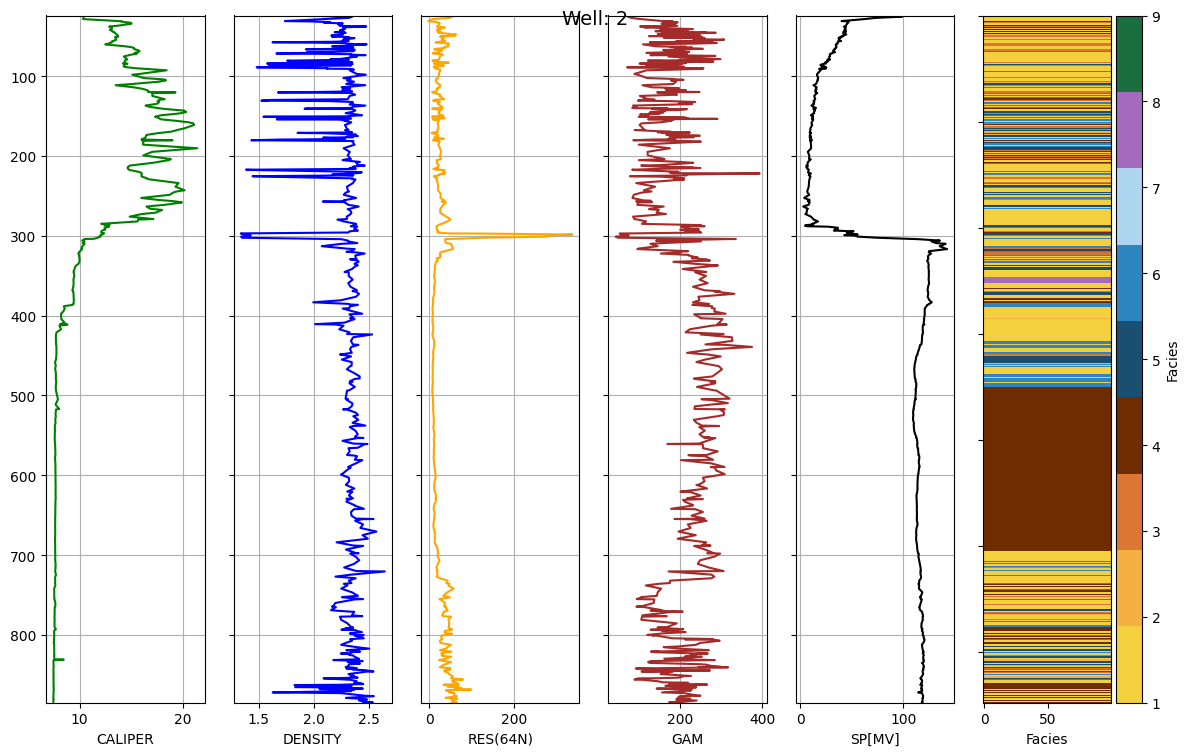

In [ ]:
make_facies_log_plot(
    df[df['WELL'] == 2],
    facies_colors)

Count of Each Unique Facies

,count
Sandstone (SST),823
Siltstone,119
Carb Shale,44
Grey Shale,222
dgs,374
coal,136
ss,369
alt,4
Shale,7


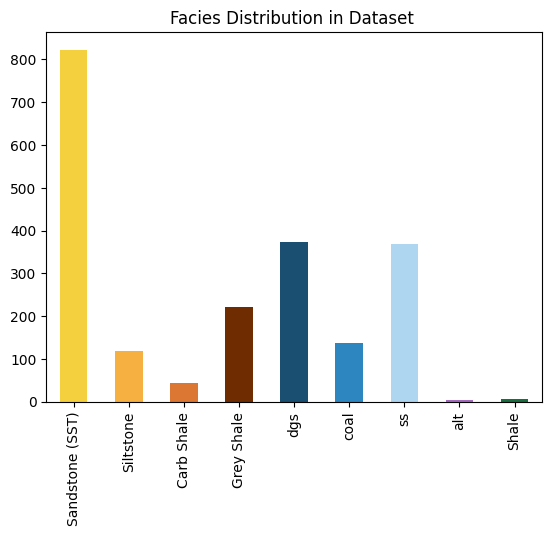

In [ ]:
facies_counts = df['Facies'].value_counts().sort_index()
#use facies labels to index each count
facies_counts.index = facies_labels

facies_counts.plot(kind='bar',color=facies_colors,
                   title='Facies Distribution in Dataset ')
facies_counts

In [ ]:
classes_to_remove = ['Shale','Siltstone']
df = df[~df['FaciesLabels'].isin(classes_to_remove)]

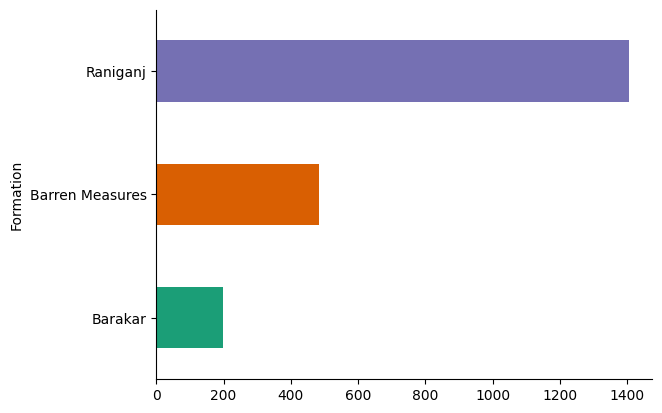

In [ ]:
df.groupby('Formation').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

In [ ]:
df.columns

Index(['DEPT[M]', 'WELL', 'CALIPER[MM]', 'DEN[GM/CC]', 'RES(64N)', 'RES[OHM]',
       'SP[MV]', 'GAM[API]', 'LITHOLOGY DESCRIPTION', 'Formation',
       'FaciesLabels', 'Facies'],
      dtype='object')

In [ ]:
# numeric columns
numeric_df = df.select_dtypes(include=['number'])

# Now compute correlation
correlation_matrix = numeric_df.corr()
print(correlation_matrix)

              DEPT[M]  CALIPER[MM]  DEN[GM/CC]  RES(64N)  RES[OHM]    SP[MV]  \
DEPT[M]      1.000000    -0.759345    0.297559  0.340991  0.247023  0.155096   
CALIPER[MM] -0.759345     1.000000   -0.426100 -0.307668 -0.095810 -0.021054   
DEN[GM/CC]   0.297559    -0.426100    1.000000  0.080024 -0.309509 -0.242003   
RES(64N)     0.340991    -0.307668    0.080024  1.000000  0.539318  0.026514   
RES[OHM]     0.247023    -0.095810   -0.309509  0.539318  1.000000  0.249311   
SP[MV]       0.155096    -0.021054   -0.242003  0.026514  0.249311  1.000000   
GAM[API]     0.067951    -0.081405   -0.011152 -0.240418 -0.286892  0.031739   
Facies      -0.061185    -0.030725   -0.108621 -0.121349 -0.139691 -0.126654   

             GAM[API]    Facies  
DEPT[M]      0.067951 -0.061185  
CALIPER[MM] -0.081405 -0.030725  
DEN[GM/CC]  -0.011152 -0.108621  
RES(64N)    -0.240418 -0.121349  
RES[OHM]    -0.286892 -0.139691  
SP[MV]       0.031739 -0.126654  
GAM[API]     1.000000  0.216025  
Facies 

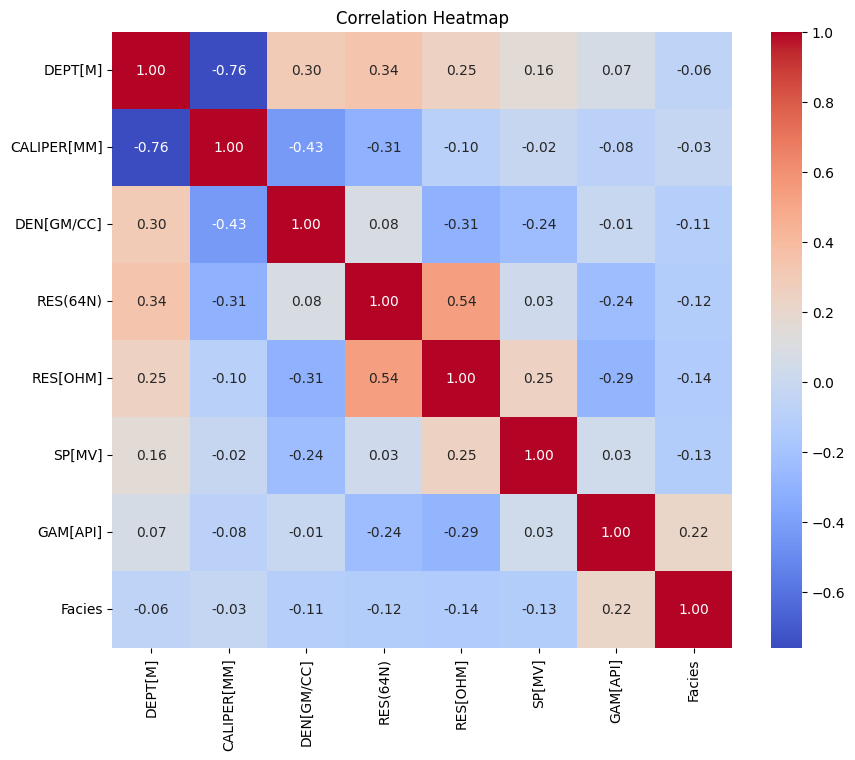

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

Feature Engineering

In [ ]:
X = df.drop(['DEPT[M]', 'Facies','FaciesLabels','Formation', 'LITHOLOGY DESCRIPTION', 'WELL'], axis=1)
y = df['Facies'].values

In [ ]:
X.head()

,CALIPER[MM],DEN[GM/CC],RES(64N),RES[OHM],SP[MV],GAM[API]
0,12.6696,2.59367,4.50623,21.0600,64.5311,77.5320
1,12.6886,2.30613,3.39083,22.2852,56.2742,79.1260
2,12.6710,2.37167,3.29750,21.9935,56.3978,78.5932
3,12.6645,2.32154,3.11173,22.5185,48.2233,74.8741
5,12.6506,2.15749,3.57612,24.0353,48.1409,114.1800


In [ ]:
from sklearn.preprocessing import StandardScaler
cols_to_scale = ['CALIPER[MM]', 'DEN[GM/CC]', 'RES(64N)', 'RES[OHM]',
        'SP[MV]', 'GAM[API]']
scaler = StandardScaler()
X[cols_to_scale] = scaler.fit_transform(X[cols_to_scale])

In [ ]:
X.head()

,CALIPER[MM],DEN[GM/CC],RES(64N),RES[OHM],SP[MV],GAM[API]
0,0.692344,0.582474,-0.886869,-1.359027,0.779073,-1.623457
1,0.698235,-0.419573,-0.905569,-1.328798,0.682502,-1.598167
2,0.692778,-0.191173,-0.907134,-1.335995,0.683947,-1.606620
3,0.690763,-0.365871,-0.910248,-1.323042,0.588341,-1.665628
5,0.686453,-0.937568,-0.902462,-1.285619,0.587377,-1.041990


In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif(data):
    vif_df = pd.DataFrame()
    vif_df['Column'] = data.columns
    vif_df['VIF'] = [variance_inflation_factor(data.values, i) for i in range(data.shape[1])]
    return vif_df

In [ ]:
calculate_vif(X[cols_to_scale])

,Column,VIF
0,CALIPER[MM],1.439269
1,DEN[GM/CC],1.582632
2,RES(64N),1.652847
3,RES[OHM],1.908301
4,SP[MV],1.128728
5,GAM[API],1.165960


In [ ]:
X_encoded = pd.get_dummies(X, drop_first=True)
X_encoded.head(3)

,CALIPER[MM],DEN[GM/CC],RES(64N),RES[OHM],SP[MV],GAM[API]
0,0.692344,0.582474,-0.886869,-1.359027,0.779073,-1.623457
1,0.698235,-0.419573,-0.905569,-1.328798,0.682502,-1.598167
2,0.692778,-0.191173,-0.907134,-1.335995,0.683947,-1.606620


Model Training

In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV

X_train, X_test, y_train, y_test = train_test_split(
        X_encoded, y, test_size=0.2, random_state=10)

Modelling

In [ ]:
from sklearn.metrics import classification_report, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
import xgboost as xgb

In [ ]:
#models and hyperparameter grids
models_and_grids = [
    (
        LogisticRegression(max_iter=1000),
        {'C': [0.1, 1, 10], 'solver': ['lbfgs', 'liblinear']}
    ),
    (
        KNeighborsClassifier(),
        {'n_neighbors': [3, 5, 7], 'weights': ['uniform', 'distance']}
    ),
    (
        xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss'),
        {'n_estimators': [50, 100], 'max_depth': [3, 5], 'learning_rate': [0.05, 0.1]}
    ),
    (
        RandomForestClassifier(random_state=42),
        {'n_estimators': [50, 100], 'max_depth': [5, 10]}
    )
]

# Rename columns to be compatible with XGBoost
X_encoded_xgb = X_encoded.copy()
X_encoded_xgb.columns = [col.replace('[', '_').replace(']', '_').replace('<', '_') for col in X_encoded_xgb.columns]

# 8. Train and tune each model
for model, param_grid in models_and_grids:
    print(f"\nTraining and tuning {model.__class__.__name__}...")
    grid = GridSearchCV(model, param_grid, cv=3, scoring='accuracy', n_jobs=-1)

    # Use the renamed DataFrame for XGBoost, otherwise use the original X_encoded
    if isinstance(model, xgb.XGBClassifier):
        # Fit XGBoost on the training split, using the renamed columns
        # Need to apply the column renaming to X_train and X_test as well
        X_train_xgb = X_train.copy()
        X_test_xgb = X_test.copy()
        X_train_xgb.columns = [col.replace('[', '_').replace(']', '_').replace('<', '_') for col in X_train_xgb.columns]
        X_test_xgb.columns = [col.replace('[', '_').replace(']', '_').replace('<', '_') for col in X_test_xgb.columns]

        grid.fit(X_train_xgb, y_train)
        best_model = grid.best_estimator_
        # Predict on the test split using the renamed columns
        y_pred = best_model.predict(X_test_xgb)
    else:
        # Fit other models on the training split
        grid.fit(X_train, y_train)
        best_model = grid.best_estimator_
        # Predict on the test split
        y_pred = best_model.predict(X_test)


    print("Best Params:", grid.best_params_)
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))


Training and tuning LogisticRegression...
Best Params: {'C': 10, 'solver': 'liblinear'}
Accuracy: 0.5
              precision    recall  f1-score   support

           0       0.46      0.91      0.61       152
           1       0.00      0.00      0.00        26
           2       0.00      0.00      0.00         7
           3       0.00      0.00      0.00        40
           4       0.65      0.89      0.75        71
           5       0.33      0.06      0.10        35
           6       0.36      0.06      0.10        87

    accuracy                           0.50       418
   macro avg       0.26      0.27      0.22       418
weighted avg       0.38      0.50      0.38       418


Training and tuning KNeighborsClassifier...


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Best Params: {'n_neighbors': 7, 'weights': 'uniform'}
Accuracy: 0.507177033492823
              precision    recall  f1-score   support

           0       0.51      0.82      0.63       152
           1       0.25      0.08      0.12        26
           2       0.00      0.00      0.00         7
           3       0.06      0.05      0.06        40
           4       0.82      0.79      0.81        71
           5       0.42      0.31      0.36        35
           6       0.45      0.20      0.27        87

    accuracy                           0.51       418
   macro avg       0.36      0.32      0.32       418
weighted avg       0.48      0.51      0.47       418


Training and tuning XGBClassifier...


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [14:50:50] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in 

Best Params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 50}
Accuracy: 0.5263157894736842
              precision    recall  f1-score   support

           0       0.48      0.95      0.63       152
           1       0.00      0.00      0.00        26
           2       0.00      0.00      0.00         7
           3       0.20      0.03      0.04        40
           4       0.87      0.77      0.82        71
           5       0.44      0.43      0.43        35
           6       0.42      0.06      0.10        87

    accuracy                           0.53       418
   macro avg       0.34      0.32      0.29       418
weighted avg       0.46      0.53      0.43       418


Training and tuning RandomForestClassifier...
Best Params: {'max_depth': 5, 'n_estimators': 100}
Accuracy: 0.5311004784688995
              precision    recall  f1-score   support

           0       0.47      0.97      0.64       152
           1       0.00      0.00      0.00        26
           

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Predictions on the test set:
      DEPT[M]     FaciesLabels Predicted_FaciesLabels
1210    29.21       Carb Shale        Sandstone (SST)
1211    29.68       Grey Shale        Sandstone (SST)
1212    30.39  Sandstone (SST)        Sandstone (SST)
1213    32.00  Sandstone (SST)        Sandstone (SST)
1214    35.00  Sandstone (SST)        Sandstone (SST)

Plotting predictions for Well 3:


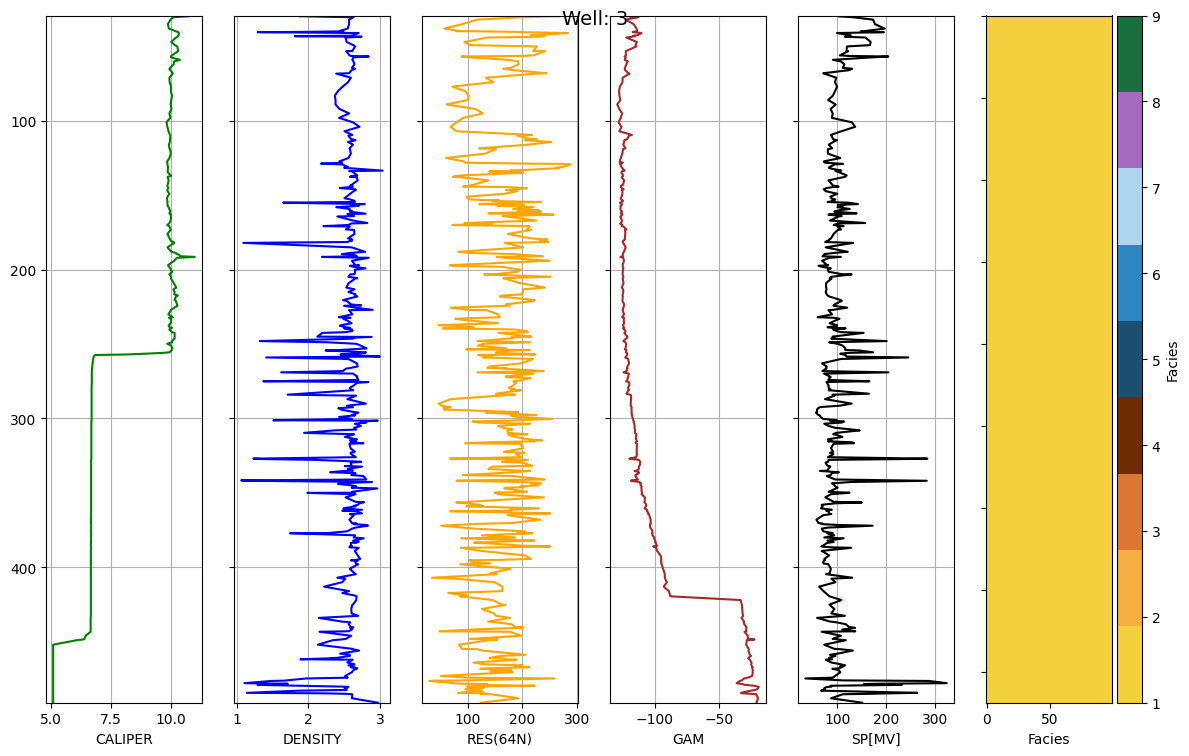

In [ ]:
# prompt: now test model for test dataset

import pandas as pd
# Evaluate on the test set
test_set = test.copy()
test_set['Facies'] = test_set['FaciesLabels'].map(class_mapping)

# Remove the same classes from the test set as from the training set
classes_to_remove_test = ['Shale','Siltstone'] # Assuming the same classes are removed
test_set = test_set[~test_set['FaciesLabels'].isin(classes_to_remove_test)]

# Prepare test data (features)
# Drop similar columns as in the training data preparation
X_test_set = test_set.drop(['DEPT[M]', 'Facies', 'FaciesLabels', 'Formation', 'LITHOLOGY DESCRIPTION', 'WELL'], axis=1)

# Scale numerical features using the same scaler fitted on the training data
X_test_set[cols_to_scale] = scaler.transform(X_test_set[cols_to_scale])

# Apply one-hot encoding to the test set features
X_test_set_encoded = pd.get_dummies(X_test_set, drop_first=True)

# Align columns between training and test sets after one-hot encoding
# This is crucial to handle cases where test set might not have all categories present in training set
train_cols = X_train.columns # Use X_train before XGBoost column renaming for alignment
X_test_set_encoded = X_test_set_encoded.reindex(columns=train_cols, fill_value=0)


# Predict on the test set using the best model (from the last iteration of the loop)
# Assuming the last trained model (which was RandomForestClassifier in the loop) is the one we want to use for the test set.
# If you want to use a different model, you would need to store the best model from the loop and use it here.
# Let's assume best_model is the last trained and tuned model (RandomForest in the provided code).

# If the best_model is XGBoost, rename the test set columns as well
if isinstance(best_model, xgb.XGBClassifier):
    X_test_set_encoded_xgb = X_test_set_encoded.copy()
    X_test_set_encoded_xgb.columns = [col.replace('[', '_').replace(']', '_').replace('<', '_') for col in X_test_set_encoded_xgb.columns]
    y_test_pred = best_model.predict(X_test_set_encoded_xgb)
else:
     y_test_pred = best_model.predict(X_test_set_encoded)


# Add predictions to the test set DataFrame
test_set['Predicted_Facies'] = y_test_pred

# Map predicted facies back to original labels for visualization if needed
predicted_facies_labels = [facies_labels[i] for i in y_test_pred] # Assuming indices match
test_set['Predicted_FaciesLabels'] = predicted_facies_labels

print("\nPredictions on the test set:")
print(test_set[['DEPT[M]', 'FaciesLabels', 'Predicted_FaciesLabels']].head())

# You can now visualize the predictions using the make_facies_log_plot function
# Need to map the predicted integer labels back to the original colors for plotting
# Create a column with the predicted integer labels
test_set_for_plot = test_set.copy()
test_set_for_plot['Facies'] = test_set_for_plot['Predicted_Facies']

print("\nPlotting predictions for Well 3:")
make_facies_log_plot(test_set_for_plot, facies_colors)

In [ ]:
# prompt: check the accurayc for the test dataset

import numpy as np
# Extract the actual target values for the test set
y_test_set_actual = test_set['Facies'].values

# Evaluate the accuracy on the test set
test_accuracy = accuracy_score(y_test_set_actual, y_test_pred)

print(f"\nAccuracy on the test dataset (Well 3): {test_accuracy}")
print("\nClassification Report on the test dataset (Well 3):")
print(classification_report(y_test_set_actual, y_test_pred, target_names=[facies_labels[i] for i in sorted(np.unique(y_test_set_actual))]))


Accuracy on the test dataset (Well 3): 0.44630071599045346

Classification Report on the test dataset (Well 3):
                 precision    recall  f1-score   support

Sandstone (SST)       0.45      1.00      0.62       187
      Siltstone       0.00      0.00      0.00        35
     Carb Shale       0.00      0.00      0.00        16
     Grey Shale       0.00      0.00      0.00        33
            dgs       0.00      0.00      0.00        14
           coal       0.00      0.00      0.00        16
             ss       0.00      0.00      0.00       118

       accuracy                           0.45       419
      macro avg       0.06      0.14      0.09       419
   weighted avg       0.20      0.45      0.28       419



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
